Dataset Loaded Successfully!

First 5 Rows:

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

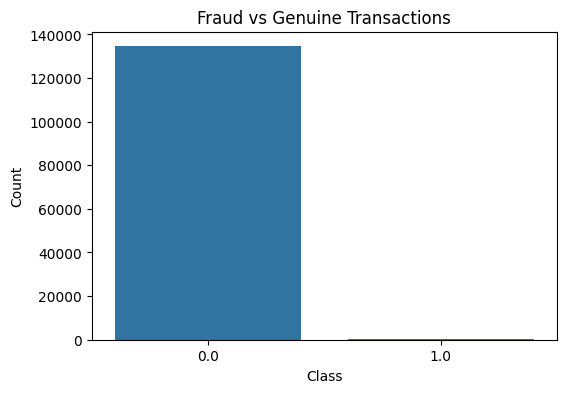


Dataset After Normalization:

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25       V26       V27      

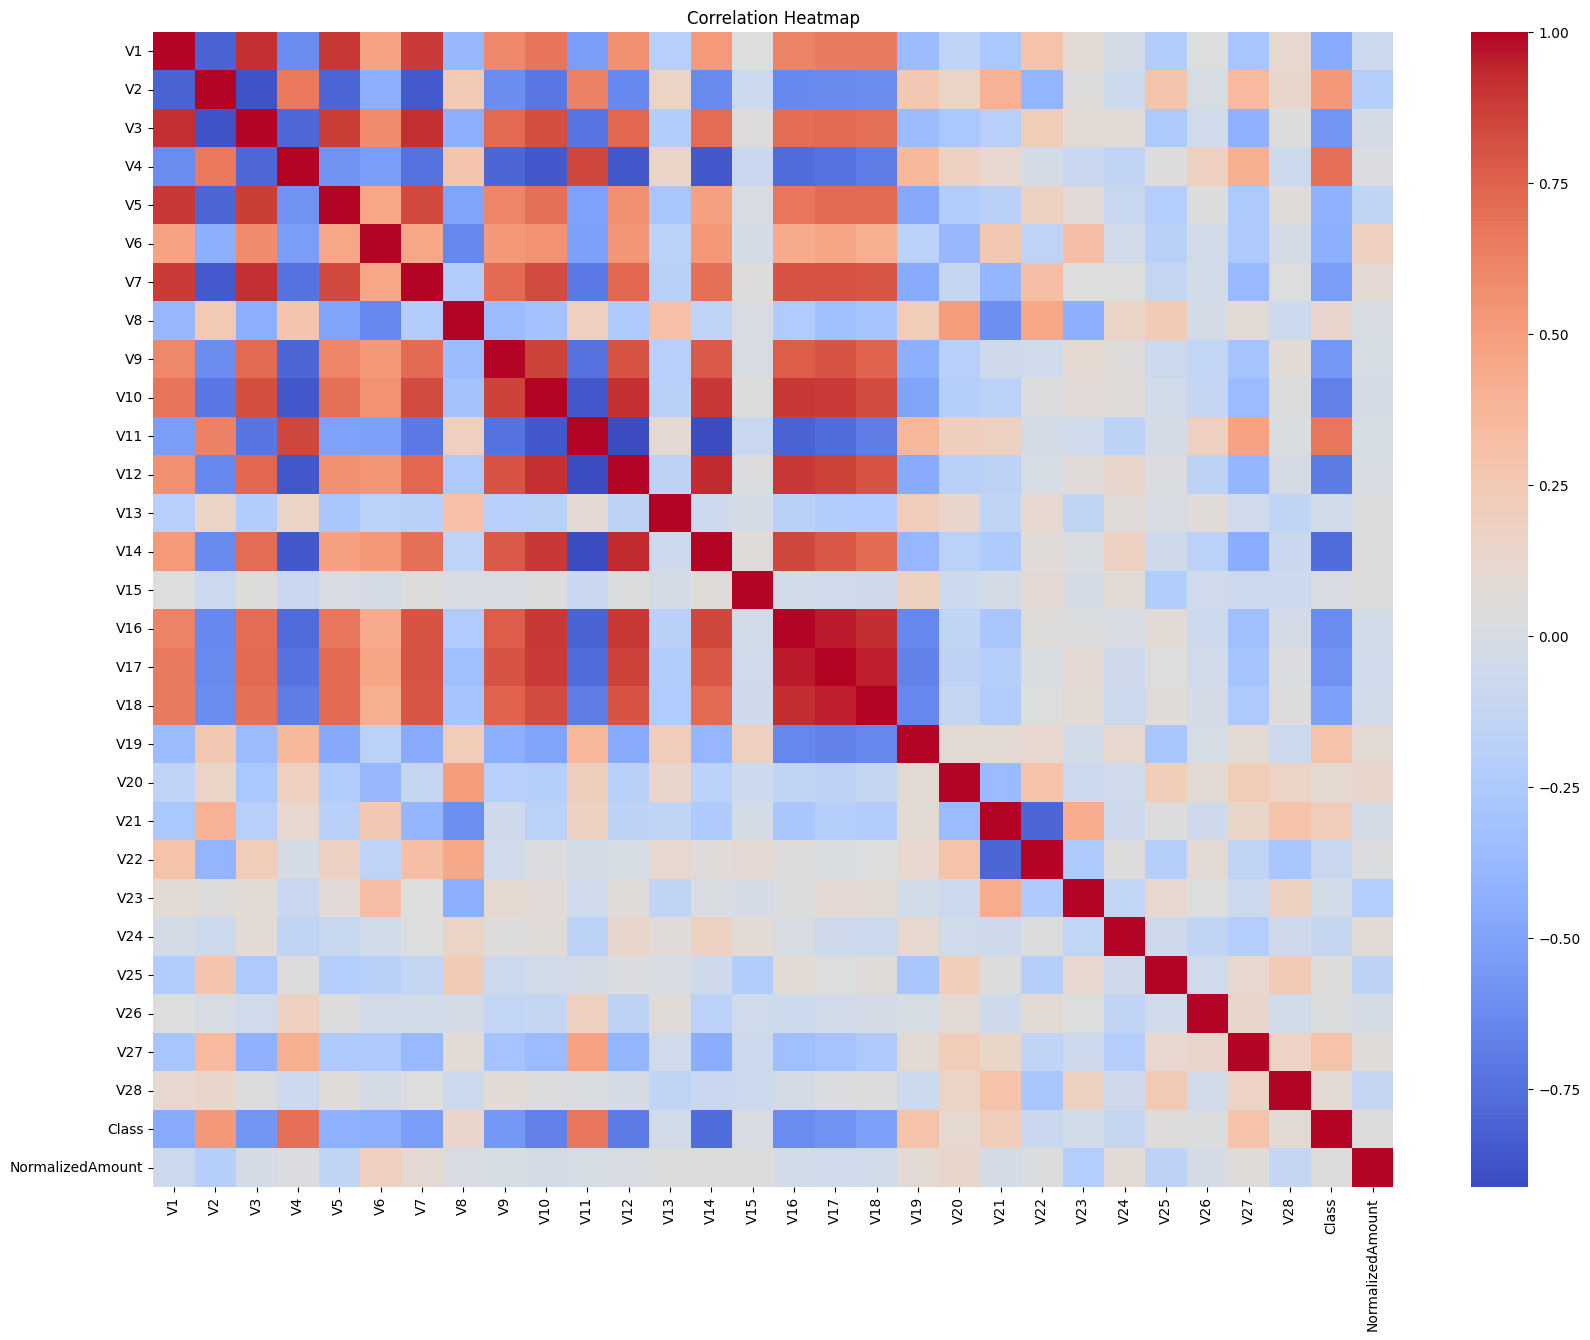


Features Shape: (269000, 29)
Target Shape: (269000,)

Training Data Shape: (215200, 29)
Testing Data Shape: (53800, 29)

Model Training Completed!

Predictions Completed!

MODEL PERFORMANCE

Accuracy Score: 0.950185873605948
Precision Score: 0.9778452319943234
Recall Score: 0.9213312038034395
F1 Score: 0.9487473704341174

Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95     26877
         1.0       0.98      0.92      0.95     26923

    accuracy                           0.95     53800
   macro avg       0.95      0.95      0.95     53800
weighted avg       0.95      0.95      0.95     53800



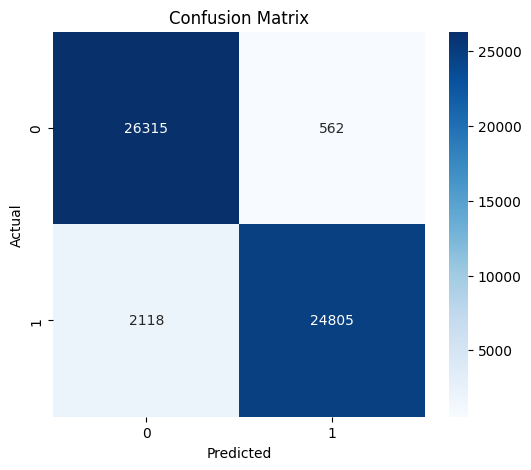


Custom Transaction Prediction:

Fraudulent Transaction Detected!

Model Saved Successfully!

Balanced Dataset Saved Successfully!

Credit Card Fraud Detection Project Completed Successfully!


In [1]:
# ==========================================
# CREDIT CARD FRAUD DETECTION PROJECT
# DATASET: creditcard.csv
# ==========================================

# ==========================================
# STEP 1 — IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils import resample

import warnings
warnings.filterwarnings('ignore')


# ==========================================
# STEP 2 — LOAD DATASET
# ==========================================

# Upload creditcard.csv in Google Colab first

df = pd.read_csv('creditcard.csv')

print("Dataset Loaded Successfully!\n")

print("First 5 Rows:\n")
print(df.head())


# ==========================================
# STEP 3 — DATASET INFORMATION
# ==========================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())


# ==========================================
# STEP 4 — CHECK CLASS DISTRIBUTION
# ==========================================

print("\nTransaction Class Distribution:\n")

print(df['Class'].value_counts())

# Visualization

plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Genuine Transactions')

plt.xlabel('Class')

plt.ylabel('Count')

plt.show()


# ==========================================
# STEP 5 — NORMALIZE AMOUNT COLUMN
# ==========================================

scaler = StandardScaler()

df['NormalizedAmount'] = scaler.fit_transform(
    df['Amount'].values.reshape(-1,1)
)

# Drop original Amount and Time columns

df.drop(['Amount', 'Time'], axis=1, inplace=True)

print("\nDataset After Normalization:\n")

print(df.head())


# ==========================================
# STEP 6 — HANDLE CLASS IMBALANCE
# ==========================================

# Separate majority and minority classes

genuine = df[df['Class'] == 0]

fraud = df[df['Class'] == 1]

print("\nGenuine Transactions:", len(genuine))

print("Fraud Transactions:", len(fraud))


# Oversample fraud transactions

fraud_oversampled = resample(
    fraud,
    replace=True,
    n_samples=len(genuine),
    random_state=42
)

# Combine balanced dataset

balanced_df = pd.concat([genuine, fraud_oversampled])

# Shuffle dataset

balanced_df = balanced_df.sample(frac=1, random_state=42)

print("\nBalanced Dataset Class Distribution:\n")

print(balanced_df['Class'].value_counts())


# ==========================================
# STEP 7 — CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(20,15))

sns.heatmap(
    balanced_df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


# ==========================================
# STEP 8 — DEFINE FEATURES AND TARGET
# ==========================================

X = balanced_df.drop('Class', axis=1)

y = balanced_df['Class']

print("\nFeatures Shape:", X.shape)

print("Target Shape:", y.shape)


# ==========================================
# STEP 9 — TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ==========================================
# STEP 10 — TRAIN MACHINE LEARNING MODEL
# ==========================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("\nModel Training Completed!")


# ==========================================
# STEP 11 — MAKE PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

print("\nPredictions Completed!")


# ==========================================
# STEP 12 — MODEL EVALUATION
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("\nMODEL PERFORMANCE\n")

print("Accuracy Score:", accuracy)

print("Precision Score:", precision)

print("Recall Score:", recall)

print("F1 Score:", f1)


# ==========================================
# STEP 13 — CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# ==========================================
# STEP 14 — CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


# ==========================================
# STEP 15 — CUSTOM PREDICTION
# ==========================================

# Sample transaction
sample_transaction = X.iloc[0:1]

prediction = model.predict(sample_transaction)

print("\nCustom Transaction Prediction:\n")

if prediction[0] == 1:
    print("Fraudulent Transaction Detected!")
else:
    print("Genuine Transaction")


# ==========================================
# STEP 16 — SAVE MODEL
# ==========================================

import joblib

joblib.dump(model, 'credit_card_fraud_detection_model.pkl')

print("\nModel Saved Successfully!")


# ==========================================
# STEP 17 — SAVE BALANCED DATASET
# ==========================================

balanced_df.to_csv(
    'balanced_creditcard_dataset.csv',
    index=False
)

print("\nBalanced Dataset Saved Successfully!")


# ==========================================
# PROJECT COMPLETED
# ==========================================

print("\nCredit Card Fraud Detection Project Completed Successfully!")